# A6 — Clasificación retórica con Gemini vía API

Evaluación de Gemini 2.0 Flash (Google AI Studio, tier de pago) para la tarea de
segmentación retórica de fragmentos de documentos científicos en español.

- Dos estrategias de prompting: zero-shot y few-shot (k=1 por etiqueta)
- Evaluación sobre el conjunto EVAL completo validado manualmente
- Registro de tokens y latencia por request para análisis A8
- Métricas: Macro F1, Micro F1, reporte por etiqueta, matriz de confusión

**SDK:** google-genai (nueva versión oficial, google.generativeai está deprecado)

## 1. Configuración

In [1]:
!pip install -q google-genai pandas scikit-learn matplotlib seaborn tqdm

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import json
import os
import re
import time
from pathlib import Path

from google import genai
from google.genai import types
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)
from tqdm.auto import tqdm

# --- rutas ---
DRIVE_ROOT  = Path("/content/drive/MyDrive")
EVAL_PATH   = DRIVE_ROOT / "consolidado_v1_fixed.csv"
RESULTS_DIR = DRIVE_ROOT / "results_a6"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- modelo ---
MODEL = "gemini-2.0-flash"

# --- costos USD por millón de tokens (gemini-2.0-flash, abril 2025) ---
COST_INPUT_PER_M  = 0.10
COST_OUTPUT_PER_M = 0.40
FREE_TIER = False

# --- parámetros de generación ---
TEMPERATURE    = 0
MAX_TOKENS     = 60
MAX_TEXT_WORDS = 700

# --- rate limiting ---
# gemini-2.0-flash paid: 1000 RPM → 0.5 s es margen de seguridad suficiente
# Si aparecen errores 429 subir a 1.0
REQUEST_DELAY = 0.5

# --- etiquetas válidas ---
LABELS = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]

# --- API key ---
api_key = os.environ.get("GOOGLE_API_KEY")
if not api_key:
    try:
        from google.colab import userdata
        api_key = userdata.get("GOOGLE_API_KEY")
    except Exception:
        pass

if not api_key:
    raise EnvironmentError("GOOGLE_API_KEY no encontrada. Agregar en Colab Secrets.")

client = genai.Client(api_key=api_key)

n_requests = 0

print(f"Modelo:        {MODEL}")
print(f"EVAL path:     {EVAL_PATH}")
print(f"Results dir:   {RESULTS_DIR}")
print(f"Free tier:     {FREE_TIER}")
print(f"Request delay: {REQUEST_DELAY} s")
print(f"Tiempo estimado por modo (~1742 filas): {1742 * REQUEST_DELAY / 60:.0f} min")

Modelo:        gemini-2.0-flash
EVAL path:     /content/drive/MyDrive/consolidado_v1_fixed.csv
Results dir:   /content/drive/MyDrive/results_a6
Free tier:     False
Request delay: 0.5 s
Tiempo estimado por modo (~1742 filas): 15 min


## 2. Carga del conjunto de evaluación

In [4]:
df_all = pd.read_csv(EVAL_PATH)

df_eval  = df_all[df_all["dataset_type"] == "EVAL"].reset_index(drop=True)
df_train = df_all[df_all["dataset_type"] == "TRAIN_TEST"].reset_index(drop=True)

df_eval = df_eval.copy()
df_eval["word_count"] = df_eval["text"].str.split().str.len()

print("Distribución del conjunto EVAL:")
print(df_eval["label"].value_counts().to_string())
print(f"\nTotal EVAL:       {len(df_eval)}")
print(f"Total TRAIN_TEST:  {len(df_train)}")
print(f"\nTiempo estimado por modo: {len(df_eval) * REQUEST_DELAY / 60:.0f} min")
print(f"Tiempo estimado total (x2): {len(df_eval) * REQUEST_DELAY * 2 / 60:.0f} min")

Distribución del conjunto EVAL:
label
INTRO    262
BACK     250
DISC     236
METH     207
RES      207
CONC     200
CONTR    196
LIM      184

Total EVAL:       1742
Total TRAIN_TEST:  16098

Tiempo estimado por modo: 15 min
Tiempo estimado total (x2): 29 min


## 3. Diseño de prompts

In [5]:
SYSTEM_PROMPT = """Eres un experto en análisis del discurso científico en español con amplio conocimiento en retórica académica.
Tu tarea es clasificar fragmentos textuales de artículos científicos según su función retórica.

Las ocho categorías posibles y sus definiciones son:

INTRO: Presenta el problema de investigación, su motivación, los objetivos del trabajo y, en algunos casos, una descripción
general del enfoque propuesto.

BACK: Describe trabajos PREVIOS de OTROS autores, no del estudio actual. Suele incluir citas bibliográficas y referencias a
investigaciones ajenas. A diferencia de INTRO (que habla del problema actual) y DISC (que interpreta resultados propios), BACK es
  revisión de literatura externa.

METH: Explica el diseño experimental, los métodos, modelos, datos, materiales y procedimientos utilizados para desarrollar el
estudio.

RES: Presenta los resultados obtenidos a partir de los experimentos, análisis empíricos o evaluaciones realizadas, generalmente
sin interpretación extensiva.

DISC: Interpreta los resultados del estudio actual, analiza sus implicaciones, los compara con trabajos previos y discute su
relevancia.

CONTR: El fragmento declara EXPLÍCITAMENTE los aportes originales del trabajo. Suele contener frases como "proponemos", "nuestra
contribución es", "presentamos un nuevo", "el aporte principal de este trabajo es", "a diferencia de trabajos previos, nuestro
método". A diferencia de DISC (que interpreta resultados) e INTRO (que describe objetivos), CONTR hace una declaración directa de
  lo que el trabajo aporta al campo.

LIM: Describe restricciones del enfoque, supuestos adoptados, posibles fuentes de error o aspectos que limitan la generalización
de los resultados. Puede incluir trabajo futuro.

CONC: Resume los principales hallazgos del trabajo y presenta las conclusiones finales o líneas de trabajo futuro.

Responde ÚNICAMENTE con un JSON válido en el formato exacto:
{"label": "<UNA DE LAS 8 ETIQUETAS>", "confidence": <número entre 0.0 y 1.0>}

No incluyas explicaciones, markdown ni texto fuera del JSON."""


# Config reutilizable para todos los requests
GEN_CONFIG = types.GenerateContentConfig(
    system_instruction=SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    max_output_tokens=MAX_TOKENS,
)


def build_user_message_zeroshot(text: str, max_words: int = MAX_TEXT_WORDS) -> str:
    words = text.split()
    if len(words) > max_words:
        text = " ".join(words[:max_words])
    return f"Clasifica el siguiente fragmento de un artículo científico en español:\n\n{text}"


print("System prompt y config listos.")

System prompt y config listos.


In [6]:
FEWSHOT_MAX_WORDS = 150

def get_fewshot_example(df: pd.DataFrame, label: str) -> str:
    subset = df[df["label"] == label].copy()
    subset["wc"] = subset["text"].str.split().str.len()
    idx = (subset["wc"] - subset["wc"].median()).abs().idxmin()
    return " ".join(subset.loc[idx, "text"].split()[:FEWSHOT_MAX_WORDS])


fewshot_examples = {
    label: get_fewshot_example(df_train, label)
    for label in LABELS
    if label in df_train["label"].unique()
}

print(f"Ejemplos few-shot: {len(fewshot_examples)} etiquetas")
for lbl, ex in fewshot_examples.items():
    print(f"  {lbl}: {len(ex.split())} palabras")

Ejemplos few-shot: 8 etiquetas
  INTRO: 150 palabras
  BACK: 150 palabras
  METH: 150 palabras
  RES: 150 palabras
  DISC: 150 palabras
  CONTR: 150 palabras
  LIM: 150 palabras
  CONC: 150 palabras


In [7]:
def build_fewshot_contents(text: str, examples: dict, max_words: int = MAX_TEXT_WORDS) -> list:
    """
    Formato multi-turn para google-genai SDK.
    Cada part es un dict {"text": "..."} (no string directo).
    role="model" (no "assistant").
    """
    contents = []
    for label, example_text in examples.items():
        contents.append(types.Content(
            role="user",
            parts=[types.Part(text=f"Clasifica el siguiente fragmento de un artículo científico en español:\n\n{example_text}")]
        ))
        contents.append(types.Content(
            role="model",
            parts=[types.Part(text=json.dumps({"label": label, "confidence": 1.0}))]
        ))

    words = text.split()
    if len(words) > max_words:
        text = " ".join(words[:max_words])
    contents.append(types.Content(
        role="user",
        parts=[types.Part(text=f"Clasifica el siguiente fragmento de un artículo científico en español:\n\n{text}")]
    ))
    return contents


print(f"Turns en un request few-shot: {len(build_fewshot_contents('test', fewshot_examples))}")

Turns en un request few-shot: 17


## 4. Pipeline de inferencia

In [8]:
def parse_label_response(raw: str) -> dict:
    raw = re.sub(r"```(?:json)?\n?", "", raw).replace("```", "").strip()
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        return None
    try:
        parsed = json.loads(match.group())
        label  = parsed.get("label", "").strip().upper()
        if label not in LABELS:
            return None
        return {"label": label, "confidence": float(parsed.get("confidence", 0.0))}
    except (json.JSONDecodeError, ValueError):
        return None


def classify_fragment(content, retries: int = 3) -> dict:
    """
    content: str (zero-shot) o list de types.Content (few-shot)
    """
    global n_requests
    result = {
        "label": None, "confidence": None,
        "tokens_in": 0, "tokens_out": 0,
        "latency_s": 0.0, "error": None,
    }
    for attempt in range(retries):
        try:
            t0 = time.time()
            response = client.models.generate_content(
                model=MODEL,
                contents=content,
                config=GEN_CONFIG,
            )
            result["latency_s"] = time.time() - t0
            n_requests += 1
            if response.usage_metadata:
                result["tokens_in"]  = response.usage_metadata.prompt_token_count or 0
                result["tokens_out"] = response.usage_metadata.candidates_token_count or 0
            raw    = response.text.strip()
            parsed = parse_label_response(raw)
            if parsed:
                result["label"]      = parsed["label"]
                result["confidence"] = parsed["confidence"]
                return result
            else:
                result["error"] = f"parse_fail: {raw[:80]}"
        except Exception as e:
            err = str(e)
            result["error"] = err[:120]
            wait = 10 if "429" in err else 2 ** attempt
            time.sleep(wait)
    return result


print("Pipeline listo.")

Pipeline listo.


In [9]:
def run_batch(
    df: pd.DataFrame,
    mode: str,
    fewshot_examples: dict = None,
    output_path: Path = None,
    resume: bool = True,
) -> pd.DataFrame:
    if output_path is None:
        output_path = RESULTS_DIR / f"predictions_{mode}.csv"

    if resume and output_path.exists():
        done     = pd.read_csv(output_path)
        done_ids = set(done["_idx"].tolist())
        print(f"Checkpoint: {len(done_ids)} ya procesados de {len(df)}.")
    else:
        done     = pd.DataFrame()
        done_ids = set()

    rows             = []
    checkpoint_every = 50

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=mode):
        if idx in done_ids:
            continue

        content = (
            build_user_message_zeroshot(row["text"])
            if mode == "zeroshot"
            else build_fewshot_contents(row["text"], fewshot_examples)
        )

        result               = classify_fragment(content)
        result["_idx"]       = idx
        result["true_label"] = row["label"]
        result["doc_id"]     = row["doc_id"]
        result["mode"]       = mode
        rows.append(result)

        time.sleep(REQUEST_DELAY)

        if len(rows) % checkpoint_every == 0:
            combined = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)
            combined.to_csv(output_path, index=False)
            done     = combined
            done_ids = set(done["_idx"].tolist())
            rows     = []

    if rows:
        combined = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)
        combined.to_csv(output_path, index=False)
    else:
        combined = done

    print(f"Guardado: {output_path} — {len(combined)} filas")
    return combined


print("run_batch lista.")

run_batch lista.


## 5. Configuración — Zero-shot & Few-shot

In [10]:
import asyncio

CONCURRENCY = 15

async def classify_async(semaphore, idx, row, mode, fewshot_examples):
    async with semaphore:
        content = (
            build_user_message_zeroshot(row["text"])
            if mode == "zeroshot"
            else build_fewshot_contents(row["text"], fewshot_examples)
        )
        result = {
            "label": None, "confidence": None,
            "tokens_in": 0, "tokens_out": 0,
            "latency_s": 0.0, "error": None,
            "_idx": idx, "true_label": row["label"],
            "doc_id": row["doc_id"], "mode": mode,
        }
        for attempt in range(3):
            try:
                t0 = time.time()
                response = await client.aio.models.generate_content(
                    model=MODEL,
                    contents=content,
                    config=GEN_CONFIG,
                )
                result["latency_s"] = time.time() - t0
                if response.usage_metadata:
                    result["tokens_in"]  = response.usage_metadata.prompt_token_count or 0
                    result["tokens_out"] = response.usage_metadata.candidates_token_count or 0
                parsed = parse_label_response(response.text.strip())
                if parsed:
                    result["label"]      = parsed["label"]
                    result["confidence"] = parsed["confidence"]
                    return result
                else:
                    result["error"] = f"parse_fail: {response.text[:80]}"
            except Exception as e:
                err = str(e)
                result["error"] = err[:120]
                await asyncio.sleep(10 if "429" in err else 2 ** attempt)
        return result


async def run_batch_async(df, mode, fewshot_examples=None, output_path=None):
    if output_path is None:
        output_path = RESULTS_DIR / f"predictions_{mode}.csv"

    if output_path.exists():
        done     = pd.read_csv(output_path)
        done_ids = set(done["_idx"].tolist())
        print(f"Checkpoint: {len(done_ids)} ya procesados de {len(df)}.")
    else:
        done     = pd.DataFrame()
        done_ids = set()

    pending = [(idx, row) for idx, row in df.iterrows() if idx not in done_ids]
    print(f"Pendientes: {len(pending)}")

    semaphore   = asyncio.Semaphore(CONCURRENCY)
    all_results = list(done.to_dict("records")) if not done.empty else []

    tasks = [
        classify_async(semaphore, idx, row, mode, fewshot_examples)
        for idx, row in pending
    ]

    completed = 0
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc=mode):
        result = await coro
        all_results.append(result)
        completed += 1
        if completed % 50 == 0:
            pd.DataFrame(all_results).to_csv(output_path, index=False)

    combined = pd.DataFrame(all_results)
    combined.to_csv(output_path, index=False)
    print(f"Guardado: {output_path} — {len(combined)} filas")
    return combined

## 6. Ejecucion — Few-shot & Zero-shot

In [11]:
async def test_single():
    row = df_eval.iloc[0]
    content = build_user_message_zeroshot(row["text"])
    try:
        response = await client.aio.models.generate_content(
            model=MODEL,
            contents=content,
            config=GEN_CONFIG,
        )
        print("Status OK")
        print("Text:", response.text[:200])
        print("Usage:", response.usage_metadata)
    except Exception as e:
        print("ERROR:", e)



In [20]:
MODEL = "gemini-2.5-flash"

await test_single()

ERROR: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


In [17]:
for m in client.models.list():
    if "flash" in m.name.lower():
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-tts-preview
models/gemini-2.5-flash-native-audio-latest
models/gemini-2.5-flash-native-audio-preview-09-2025
models/gemini-2.5-flash-native-audio-preview-12-2025
models/gemini-3.1-flash-live-preview


In [ ]:
MODEL = "gemini-flash-latest"
await test_single()

In [13]:
# --- Zero-shot (retoma desde checkpoint) ---
preds_zs = await run_batch_async(
    df_eval,
    mode="zeroshot",
    output_path=RESULTS_DIR / "predictions_zeroshot.csv",
)
print(f"Zero-shot: {len(preds_zs)} | Fallidos: {preds_zs['label'].isna().sum()}")

# --- Few-shot async ---
preds_fs = await run_batch_async(
    df_eval,
    mode="fewshot",
    fewshot_examples=fewshot_examples,
    output_path=RESULTS_DIR / "predictions_fewshot.csv",
)
print(f"Few-shot: {len(preds_fs)} | Fallidos: {preds_fs['label'].isna().sum()}")

Pendientes: 1742


zeroshot:   0%|          | 0/1742 [00:00<?, ?it/s]

Guardado: /content/drive/MyDrive/results_a6/predictions_zeroshot.csv — 1742 filas
Zero-shot: 1742 | Fallidos: 0
Pendientes: 1742


fewshot:   0%|          | 0/1742 [00:00<?, ?it/s]

Guardado: /content/drive/MyDrive/results_a6/predictions_fewshot.csv — 1742 filas
Few-shot: 1742 | Fallidos: 0


In [14]:
for modo, preds in [("Zero-shot", preds_zs), ("Few-shot", preds_fs)]:
    print(f"\n{'='*50}")
    print(f"{modo}")
    print(f"{'='*50}")
    sample = preds[["true_label", "label", "confidence"]].sample(5, random_state=42)
    sample["correcto"] = sample["true_label"] == sample["label"]
    print(sample.to_string(index=False))


Zero-shot
true_label label  confidence  correcto
      CONC   RES         0.9     False
     INTRO INTRO         0.9      True
     CONTR INTRO         0.9     False
       RES   RES         0.8      True
       RES  BACK         0.9     False

Few-shot
true_label label  confidence  correcto
       LIM   LIM         1.0      True
      CONC  CONC         0.8      True
      BACK  BACK         1.0      True
       RES  METH         1.0     False
      METH  METH         1.0      True


## 7. Métricas de clasificación

In [15]:
def evaluate(preds_df: pd.DataFrame, mode_name: str) -> dict:
  valid    = preds_df.dropna(subset=["label"]).copy()
  n_failed = len(preds_df) - len(valid)
  y_true   = valid["true_label"].tolist()
  y_pred   = valid["label"].tolist()

  macro_f1 = f1_score(y_true, y_pred, average="macro", labels=LABELS, zero_division=0)
  micro_f1 = f1_score(y_true, y_pred, average="micro", labels=LABELS, zero_division=0)

  print(f"{'='*55}")
  print(f"Modo: {mode_name}  |  Modelo: {MODEL}")
  print(f"Macro F1: {macro_f1:.4f}")
  print(f"Micro F1: {micro_f1:.4f}")
  print(f"Requests fallidos: {n_failed}/{len(preds_df)}")
  print()
  print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

  return {
      "mode": mode_name, "macro_f1": macro_f1, "micro_f1": micro_f1,
      "n_valid": len(valid), "n_failed": n_failed,
      "y_true": y_true, "y_pred": y_pred,
  }


metrics_zs = evaluate(preds_zs, "Zero-shot")
metrics_fs = evaluate(preds_fs, "Few-shot k=1")

Modo: Zero-shot  |  Modelo: gemini-2.5-flash-lite
Macro F1: 0.4426
Micro F1: 0.4661
Requests fallidos: 0/1742

              precision    recall  f1-score   support

       INTRO       0.38      0.73      0.50       262
        BACK       0.24      0.41      0.30       250
        METH       0.68      0.91      0.78       207
         RES       0.48      0.28      0.35       207
        DISC       0.44      0.37      0.40       236
       CONTR       0.33      0.01      0.01       196
         LIM       0.90      0.34      0.49       184
        CONC       0.83      0.61      0.70       200

    accuracy                           0.47      1742
   macro avg       0.54      0.46      0.44      1742
weighted avg       0.52      0.47      0.44      1742

Modo: Few-shot k=1  |  Modelo: gemini-2.5-flash-lite
Macro F1: 0.4945
Micro F1: 0.5184
Requests fallidos: 0/1742

              precision    recall  f1-score   support

       INTRO       0.42      0.55      0.48       262
        BACK   

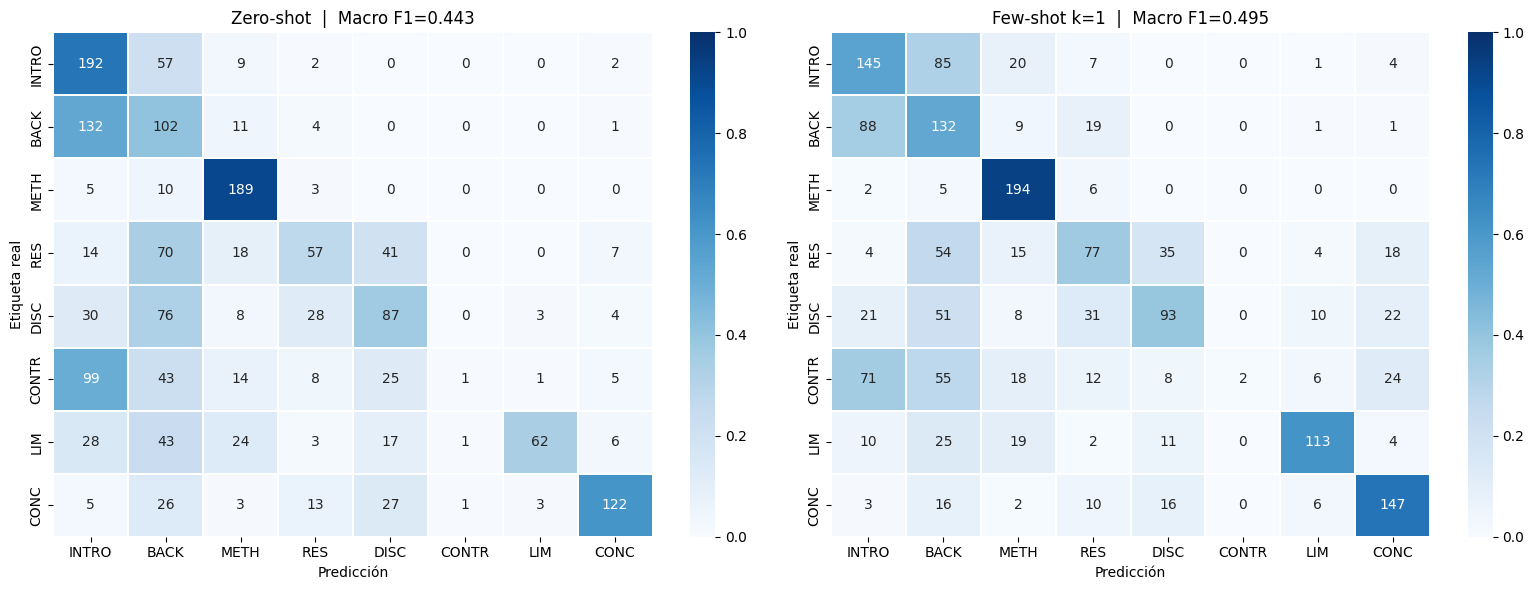

In [16]:
def plot_confusion_matrix(metrics: dict, ax: plt.Axes):
    cm      = confusion_matrix(metrics["y_true"], metrics["y_pred"], labels=LABELS)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt="d", cmap="Blues",
        xticklabels=LABELS, yticklabels=LABELS,
        vmin=0, vmax=1, ax=ax, linewidths=0.3,
    )
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")
    ax.set_title(f"{metrics['mode']}  |  Macro F1={metrics['macro_f1']:.3f}")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix(metrics_zs, axes[0])
plot_confusion_matrix(metrics_fs, axes[1])
plt.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
from sklearn.metrics import accuracy_score

print("=" * 55)
print(f"{'Modelo':<25} {'Accuracy':>9} {'Macro F1':>9} {'Micro F1':>9}")
print("-" * 55)

for mode_name, preds in [("Gemini ZS (zero-shot)", preds_zs), ("Gemini FS (few-shot k=1)", preds_fs)]:
    valid  = preds.dropna(subset=["label"])
    y_true = valid["true_label"].tolist()
    y_pred = valid["label"].tolist()
    acc    = accuracy_score(y_true, y_pred)
    maf1   = f1_score(y_true, y_pred, average="macro",  labels=LABELS, zero_division=0)
    mif1   = f1_score(y_true, y_pred, average="micro",  labels=LABELS, zero_division=0)
    print(f"{mode_name:<25} {acc:>9.4f} {maf1:>9.4f} {mif1:>9.4f}")

print("=" * 55)
print(f"  Accuracy:  {accuracy_score(preds_fs.dropna(subset=['label'])['true_label'],
preds_fs.dropna(subset=['label'])['label']):.2%}")
print(f"  Macro F1:  {f1_score(preds_fs.dropna(subset=['label'])['true_label'], preds_fs.dropna(subset=['label'])['label'],
average='macro', labels=LABELS, zero_division=0):.2%}")
print(f"  Micro F1:  {f1_score(preds_fs.dropna(subset=['label'])['true_label'], preds_fs.dropna(subset=['label'])['label'],
average='micro', labels=LABELS, zero_division=0):.2%}")

Modelo                     Accuracy  Macro F1  Micro F1
-------------------------------------------------------
Gemini ZS (zero-shot)        0.4661    0.4426    0.4661
Gemini FS (few-shot k=1)     0.5184    0.4945    0.5184
  Accuracy:  51.84%
  Macro F1:  49.45%
  Micro F1:  51.84%


## 8. Análisis de costo y latencia (A8)

In [21]:
def cost_report(preds_df: pd.DataFrame, mode_name: str):
    total_in  = preds_df["tokens_in"].sum()
    total_out = preds_df["tokens_out"].sum()
    cost_usd  = (total_in / 1e6) * COST_INPUT_PER_M + (total_out / 1e6) * COST_OUTPUT_PER_M
    lat       = preds_df["latency_s"]

    print(f"{'='*50}")
    print(f"Modo: {mode_name}  |  Modelo: {MODEL}")
    print(f"Tokens entrada:     {total_in:,}")
    print(f"Tokens salida:      {total_out:,}")
    print(f"Costo USD:          ${0.0 if FREE_TIER else cost_usd:.4f}{'  (free tier)' if FREE_TIER else ''}")
    print(f"Costo/1000 docs:    ${cost_usd/len(preds_df)*1000:.4f} USD")
    print(f"Latencia media:     {lat.mean():.2f} s")
    print(f"Latencia p95:       {lat.quantile(0.95):.2f} s")
    print()


cost_report(preds_zs, "Zero-shot")
cost_report(preds_fs, "Few-shot k=1")

Modo: Zero-shot  |  Modelo: gemini-2.5-flash
Tokens entrada:     1,806,156
Tokens salida:      36,667
Costo USD:          $0.1953
Costo/1000 docs:    $0.1121 USD
Latencia media:     2.63 s
Latencia p95:       8.22 s

Modo: Few-shot k=1  |  Modelo: gemini-2.5-flash
Tokens entrada:     5,645,524
Tokens salida:      25,058
Costo USD:          $0.5746
Costo/1000 docs:    $0.3298 USD
Latencia media:     1.80 s
Latencia p95:       5.22 s



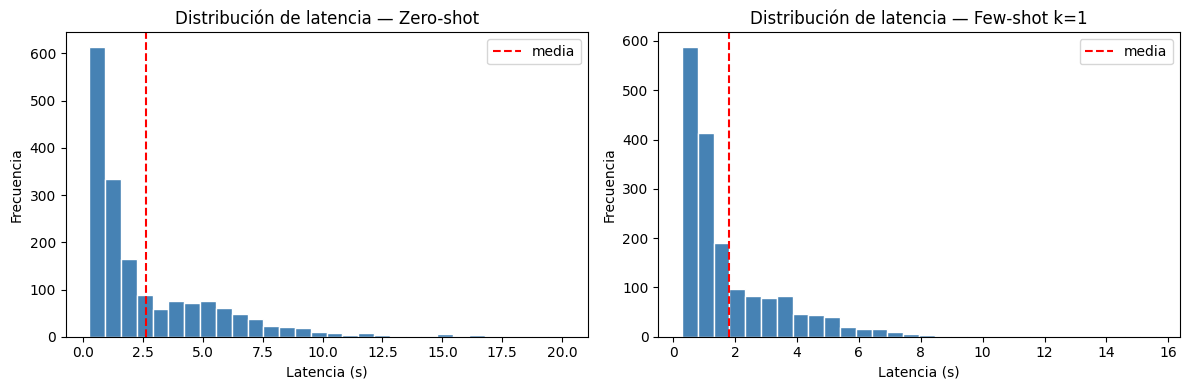

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in [
    (axes[0], preds_zs, "Zero-shot"),
    (axes[1], preds_fs, "Few-shot k=1"),
]:
    ax.hist(preds["latency_s"], bins=30, edgecolor="white", color="steelblue")
    ax.axvline(preds["latency_s"].mean(), color="red", linestyle="--", label="media")
    ax.set_title(f"Distribución de latencia — {title}")
    ax.set_xlabel("Latencia (s)")
    ax.set_ylabel("Frecuencia")
    ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / "latency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Análisis de errores

In [23]:
def error_analysis(preds_df: pd.DataFrame, mode_name: str, top_n: int = 10):
    valid  = preds_df.dropna(subset=["label"]).copy()
    errors = valid[valid["true_label"] != valid["label"]].copy()
    print(f"Modo: {mode_name}")
    print(f"Errores: {len(errors)} / {len(valid)} ({len(errors)/len(valid)*100:.1f}%)")
    errors["pair"] = errors["true_label"] + " -> " + errors["label"]
    print(f"\nTop {top_n} pares de confusión:")
    print(errors["pair"].value_counts().head(top_n).to_string())
    error_by_label = (
        errors.groupby("true_label").size() / valid.groupby("true_label").size()
    ).sort_values(ascending=False)
    print("\nTasa de error por etiqueta:")
    print(error_by_label.round(3).to_string())
    print()


error_analysis(preds_zs, "Zero-shot")
error_analysis(preds_fs, "Few-shot k=1")

Modo: Zero-shot
Errores: 930 / 1742 (53.4%)

Top 10 pares de confusión:
pair
BACK -> INTRO     132
CONTR -> INTRO     99
DISC -> BACK       76
RES -> BACK        70
INTRO -> BACK      57
LIM -> BACK        43
CONTR -> BACK      43
RES -> DISC        41
DISC -> INTRO      30
LIM -> INTRO       28

Tasa de error por etiqueta:
true_label
CONTR    0.995
RES      0.725
LIM      0.663
DISC     0.631
BACK     0.592
CONC     0.390
INTRO    0.267
METH     0.087

Modo: Few-shot k=1
Errores: 839 / 1742 (48.2%)

Top 10 pares de confusión:
pair
BACK -> INTRO     88
INTRO -> BACK     85
CONTR -> INTRO    71
CONTR -> BACK     55
RES -> BACK       54
DISC -> BACK      51
RES -> DISC       35
DISC -> RES       31
LIM -> BACK       25
CONTR -> CONC     24

Tasa de error por etiqueta:
true_label
CONTR    0.990
RES      0.628
DISC     0.606
BACK     0.472
INTRO    0.447
LIM      0.386
CONC     0.265
METH     0.063



In [24]:
def show_error_examples(preds_df, true_label, pred_label, n=3):
    valid  = preds_df.dropna(subset=["label"])
    mask   = (valid["true_label"] == true_label) & (valid["label"] == pred_label)
    for i, (_, row) in enumerate(valid[mask].head(n).iterrows(), 1):
        match = df_eval[df_eval.index == row["_idx"]]
        if match.empty:
            continue
        text = match.iloc[0]["text"]
        print(f"--- Ej. {i} | Real: {true_label} | Pred: {pred_label} | Conf: {row['confidence']:.2f} ---")
        print(text[:400], "..." if len(text) > 400 else "")
        print()


print("=== DISC -> CONC ===")
show_error_examples(preds_zs, "DISC", "CONC")
print("=== INTRO -> BACK ===")
show_error_examples(preds_zs, "INTRO", "BACK")

=== DISC -> CONC ===
--- Ej. 1 | Real: DISC | Pred: CONC | Conf: 0.90 ---
En conclusi��n podemos decir que durante toda esta etapa rein�� la confusi��n en el
proceso de descentralizaci��n del Estado, agravado en el sector educativo por el desorden
administrativo y la indefinici��n de funciones y competencias entre los niveles territoriales,
todo lo cual ha generado duplicidades en la planeaci��n, la gesti��n, el control, la
informaci��n y la evaluaci��n41. En esta trans ...

--- Ej. 2 | Real: DISC | Pred: CONC | Conf: 0.90 ---
de microorganismos. Por lo tanto, este punto deber��a ser una zona donde el equipo de limpieza y
desinfecci��n interno preste especial atenci��n.
El resultado obtenido no implica que la f��brica est�� completamente libre de
microorganismos, pues en el an��lisis solo se han considerado aquellos que formaron colonias en
las placas empleadas, con Compass Listeria Agar. Sin embargo, los resultados s�� ...

--- Ej. 3 | Real: DISC | Pred: CONC | Conf: 0.80 ---
impone a

## 10. Resumen comparativo (para el informe A7/A8)

In [25]:
summary_rows = []
for metrics, preds in [(metrics_zs, preds_zs), (metrics_fs, preds_fs)]:
    total_in  = preds["tokens_in"].sum()
    total_out = preds["tokens_out"].sum()
    cost      = (total_in / 1e6) * COST_INPUT_PER_M + (total_out / 1e6) * COST_OUTPUT_PER_M
    summary_rows.append({
        "Estrategia":        metrics["mode"],
        "Modelo":            MODEL,
        "N eval":            metrics["n_valid"] + metrics["n_failed"],
        "Macro F1":          round(metrics["macro_f1"], 4),
        "Micro F1":          round(metrics["micro_f1"], 4),
        "Costo USD":         round(0.0 if FREE_TIER else cost, 4),
        "Latencia media s":  round(preds["latency_s"].mean(), 2),
        "Requests validos":  metrics["n_valid"],
        "Requests fallidos": metrics["n_failed"],
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(RESULTS_DIR / "summary_a6.csv", index=False)
print(f"\nGuardado: {RESULTS_DIR / 'summary_a6.csv'}")

  Estrategia           Modelo  N eval  Macro F1  Micro F1  Costo USD  Latencia media s  Requests validos  Requests fallidos
   Zero-shot gemini-2.5-flash    1742    0.4426    0.4661     0.1953              2.63              1742                  0
Few-shot k=1 gemini-2.5-flash    1742    0.4945    0.5184     0.5746              1.80              1742                  0

Guardado: /content/drive/MyDrive/results_a6/summary_a6.csv


### Segund Prueba Modelo Comercial de GEMINI

In [26]:
SYSTEM_PROMPT = """Eres un experto en análisis del discurso científico en español con amplio conocimiento en retórica académica.
Tu tarea es clasificar fragmentos textuales de artículos científicos según su función retórica.

Las ocho categorías posibles y sus definiciones son:

INTRO: Presenta el problema de investigación, su motivación, los objetivos del trabajo y, en algunos casos, una descripción
general del enfoque propuesto.

BACK: Describe trabajos PREVIOS de OTROS autores, no del estudio actual. Suele incluir citas bibliográficas y referencias a
investigaciones ajenas. A diferencia de INTRO (que habla del problema actual) y DISC (que interpreta resultados propios), BACK es
  revisión de literatura externa.

METH: Explica el diseño experimental, los métodos, modelos, datos, materiales y procedimientos utilizados para desarrollar el
estudio.

RES: Presenta los resultados obtenidos a partir de los experimentos, análisis empíricos o evaluaciones realizadas, generalmente
sin interpretación extensiva.

DISC: Interpreta los resultados del estudio actual, analiza sus implicaciones, los compara con trabajos previos y discute su
relevancia.

CONTR: El fragmento declara EXPLÍCITAMENTE los aportes originales del trabajo. Suele contener frases como "proponemos", "nuestra
contribución es", "presentamos un nuevo", "el aporte principal de este trabajo es", "a diferencia de trabajos previos, nuestro
método". A diferencia de DISC (que interpreta resultados) e INTRO (que describe objetivos), CONTR hace una declaración directa de
  lo que el trabajo aporta al campo.

LIM: Describe restricciones del enfoque, supuestos adoptados, posibles fuentes de error o aspectos que limitan la generalización
de los resultados. Puede incluir trabajo futuro.

CONC: Resume los principales hallazgos del trabajo y presenta las conclusiones finales o líneas de trabajo futuro.

Responde ÚNICAMENTE con un JSON válido en el formato exacto:
{"label": "<UNA DE LAS 8 ETIQUETAS>", "confidence": <número entre 0.0 y 1.0>}

No incluyas explicaciones, markdown ni texto fuera del JSON."""


GEN_CONFIG = types.GenerateContentConfig(
    system_instruction=SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    max_output_tokens=MAX_TOKENS,
)

print("Prompt mejorado listo.")

Prompt mejorado listo.


In [27]:
FEWSHOT_MAX_WORDS = 150
HARD_LABELS = {"CONTR", "BACK", "DISC"}  # k=2 para estas

def get_fewshot_examples(df: pd.DataFrame, label: str, k: int) -> list:
    subset = df[df["label"] == label].copy()
    subset["wc"] = subset["text"].str.split().str.len()
    subset = subset.sort_values("wc")
    # toma k ejemplos distribuidos (primero cerca de la mediana, segundo cerca del p25)
    indices = []
    idx_med = (subset["wc"] - subset["wc"].median()).abs().idxmin()
    indices.append(idx_med)
    if k > 1:
        remaining = subset.drop(idx_med)
        idx_p25 = (remaining["wc"] - remaining["wc"].quantile(0.25)).abs().idxmin()
        indices.append(idx_p25)
    return [" ".join(subset.loc[i, "text"].split()[:FEWSHOT_MAX_WORDS]) for i in indices]


fewshot_examples = {}
for label in LABELS:
    if label not in df_train["label"].unique():
        continue
    k = 2 if label in HARD_LABELS else 1
    fewshot_examples[label] = get_fewshot_examples(df_train, label, k)

print(f"Ejemplos few-shot:")
for lbl, exs in fewshot_examples.items():
    print(f"  {lbl}: {len(exs)} ejemplo(s)")

Ejemplos few-shot:
  INTRO: 1 ejemplo(s)
  BACK: 2 ejemplo(s)
  METH: 1 ejemplo(s)
  RES: 1 ejemplo(s)
  DISC: 2 ejemplo(s)
  CONTR: 2 ejemplo(s)
  LIM: 1 ejemplo(s)
  CONC: 1 ejemplo(s)


In [28]:
def build_fewshot_contents(text: str, examples: dict, max_words: int = MAX_TEXT_WORDS) -> list:
    contents = []
    for label, example_list in examples.items():
        for example_text in example_list:
            contents.append(types.Content(
                role="user",
                parts=[types.Part(text=f"Clasifica el siguiente fragmento de un artículo científico en español:\n\n{example_text}")]
            ))
            contents.append(types.Content(
                role="model",
                parts=[types.Part(text=json.dumps({"label": label, "confidence": 1.0}))]
            ))

    words = text.split()
    if len(words) > max_words:
        text = " ".join(words[:max_words])
    contents.append(types.Content(
        role="user",
        parts=[types.Part(text=f"Clasifica el siguiente fragmento de un artículo científico en español:\n\n{text}")]
    ))
    return contents

print(f"Turns en un request few-shot: {len(build_fewshot_contents('test', fewshot_examples))}")

Turns en un request few-shot: 23


In [29]:
preds_zs_v2 = await run_batch_async(
    df_eval,
    mode="zeroshot",
    output_path=RESULTS_DIR / "predictions_zeroshot_v2.csv",
)
print(f"Zero-shot v2: {len(preds_zs_v2)} | Fallidos: {preds_zs_v2['label'].isna().sum()}")

preds_fs_v2 = await run_batch_async(
    df_eval,
    mode="fewshot",
    fewshot_examples=fewshot_examples,
    output_path=RESULTS_DIR / "predictions_fewshot_v2.csv",
)
print(f"Few-shot v2: {len(preds_fs_v2)} | Fallidos: {preds_fs_v2['label'].isna().sum()}")

Pendientes: 1742


zeroshot:   0%|          | 0/1742 [00:00<?, ?it/s]

Guardado: /content/drive/MyDrive/results_a6/predictions_zeroshot_v2.csv — 1742 filas
Zero-shot v2: 1742 | Fallidos: 1705
Pendientes: 1742


fewshot:   0%|          | 0/1742 [00:00<?, ?it/s]

Guardado: /content/drive/MyDrive/results_a6/predictions_fewshot_v2.csv — 1742 filas
Few-shot v2: 1742 | Fallidos: 468


### Métricas: Run 2

In [ ]:
metrics_zs_v2 = evaluate(preds_zs_v2, "Zero-shot v2")
metrics_fs_v2 = evaluate(preds_fs_v2, "Few-shot k=1 v2")

### Matrices de Confusión: Run 2

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix(metrics_zs_v2, axes[0])
plot_confusion_matrix(metrics_fs_v2, axes[1])
plt.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrices_v2.png", dpi=150, bbox_inches="tight")
plt.show()

### Costos y Latencia: Run 2

In [ ]:
cost_report(preds_zs_v2, "Zero-shot v2")
cost_report(preds_fs_v2, "Few-shot k=1 v2")

### Distribución Latencia: Run 2

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in [
    (axes[0], preds_zs_v2, "Zero-shot v2"),
    (axes[1], preds_fs_v2, "Few-shot k=1 v2"),
]:
    ax.hist(preds["latency_s"], bins=30, edgecolor="white", color="steelblue")
    ax.axvline(preds["latency_s"].mean(), color="red", linestyle="--", label="media")
    ax.set_title(f"Distribución de latencia — {title}")
    ax.set_xlabel("Latencia (s)")
    ax.set_ylabel("Frecuencia")
    ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / "latency_distribution_v2.png", dpi=150, bbox_inches="tight")
plt.show()

### Análisis de Error: Run 2

In [ ]:
error_analysis(preds_zs_v2, "Zero-shot v2")
error_analysis(preds_fs_v2, "Few-shot k=1 v2")

### Comparación Final: Todos los Experimentos

In [ ]:
from sklearn.metrics import accuracy_score

print("=" * 65)
print(f"{'Run':<28} {'Accuracy':>9} {'Macro F1':>9} {'Micro F1':>9}")
print("-" * 65)

runs = [
    ("Gemini ZS v1 (baseline)",   preds_zs),
    ("Gemini FS v1 (baseline)",   preds_fs),
    ("Gemini ZS v2 (mejorado)",   preds_zs_v2),
    ("Gemini FS v2 (mejorado)",   preds_fs_v2),
]

summary_rows = []
for name, preds in runs:
    valid  = preds.dropna(subset=["label"])
    y_true = valid["true_label"].tolist()
    y_pred = valid["label"].tolist()
    acc    = accuracy_score(y_true, y_pred)
    maf1   = f1_score(y_true, y_pred, average="macro",  labels=LABELS, zero_division=0)
    mif1   = f1_score(y_true, y_pred, average="micro",  labels=LABELS, zero_division=0)
    print(f"{name:<28} {acc:>9.4f} {maf1:>9.4f} {mif1:>9.4f}")
    summary_rows.append({"Run": name, "Accuracy": acc, "Macro F1": maf1, "Micro F1": mif1})

print("=" * 65)
pd.DataFrame(summary_rows).to_csv(RESULTS_DIR / "summary_all_runs.csv", index=False)
print(f"\nGuardado: {RESULTS_DIR / 'summary_all_runs.csv'}")